# Chile — Urban Primacy and Regional Concentration
## Memoria de Título · Diego Carmine Ortiz · UdeC 2026

Empirical evidence for **Paso 1** of the thesis argument: Chile exhibits excess urban primacy
relative to its income level (Henderson 2000), sustained regional concentration (2013–2023),
and limited sigma-convergence across regions.

| Cell | Content |
|------|---------|
| 2 | Imports · config · hardcoded datasets (Henderson, OECD) |
| 3 | Load PIBR + population · compute PIB pc · shares |
| 4 | Summary table → `data/chile_primacy_summary.csv` |
| 5 | Fig 1 — Henderson optimal primacy curve |
| 6 | Fig 2 — Regional GDP shares 2013–2023 |
| 7 | Fig 3 — Sigma-convergence (CV of regional PIB pc) |

**Sources:** BCCh Cuentas Nacionales Regionales · INE Proyecciones 2017 ·
Henderson (2000) · Lee (2025) · World Bank WDI

In [7]:
# ============================================================
# CHILE — Primacía Urbana y Concentración Regional
# Memoria de Título · Diego Carmine Ortiz · UdeC 2026
# ============================================================
%matplotlib inline

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy.interpolate import make_interp_spline
from scipy.stats import linregress
from IPython.display import display

warnings.filterwarnings('ignore')
os.makedirs('figures', exist_ok=True)
os.makedirs('data',    exist_ok=True)

# ── Global style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'font.family':      'serif',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        False,
    'axes.edgecolor':   '#BBBBBB',
    'xtick.color':      '#555555',
    'ytick.color':      '#555555',
})

def _hgrid(ax, alpha=0.3):
    'Tenue grid horizontal solamente.'
    ax.yaxis.grid(True, color='#CCCCCC', lw=0.5, alpha=alpha)
    ax.set_axisbelow(True)


def save_fig(fig, name, dpi=300):
    path = f'figures/{name}.png'
    fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white')
    print(f'  Saved: {path}')


# ── File paths ────────────────────────────────────────────────
PATH_PIBR = '/Users/diego/Desktop/MT/Datos/PIBR_REGIONES.csv'
PATH_POP  = ('/Users/diego/Desktop/MT/Datos/'
             'ine_estimaciones-y-proyecciones-2002-2035'
             '_base-2017_reg_\u00e1rea_base.csv')  # 'área' with accent

YEARS_PIBR = list(range(2013, 2024))

# ── Region tiers (names must match PIBR exactly) ──────────────
TIER1 = ['Región Metropolitana De Santiago']
TIER2 = [
    'Región Del Biobío',
    'Región De Valparaíso',
    'Región De Antofagasta',
]
TIER3 = [
    "Región Del Libertador Gral. Bernardo O'higgins",
    'Región Del Maule',
    'Región De La Araucanía',
    'Región De Los Lagos',
]
TIERS_ALL = TIER1 + TIER2 + TIER3

SHORT = {
    'Región Metropolitana De Santiago':                       'Santiago (RM)',
    'Región Del Biobío':                                      'Biobío',
    'Región De Valparaíso':                                   'Valparaíso',
    'Región De Antofagasta':                                  'Antofagasta',
    "Región Del Libertador Gral. Bernardo O'higgins":         "O'Higgins",
    'Región Del Maule':                                       'Maule',
    'Región De La Araucanía':                                 'Araucanía',
    'Región De Los Lagos':                                    'Los Lagos',
}

# Population REGION code → name (must match PIBR names exactly)
REGION_MAP = {
     1: 'Región De Tarapacá',
     2: 'Región De Antofagasta',
     3: 'Región De Atacama',
     4: 'Región De Coquimbo',
     5: 'Región De Valparaíso',
     6: "Región Del Libertador Gral. Bernardo O'higgins",
     7: 'Región Del Maule',
     8: 'Región Del Biobío',
     9: 'Región De La Araucanía',
    10: 'Región De Los Lagos',
    11: 'Región De Aysén Del Gral. Carlos Ibáñez Del Campo',
    12: 'Región De Magallanes Y De La Antártica Chilena',
    13: 'Región Metropolitana De Santiago',
    14: 'Región De Los Ríos',
    15: 'Región De Arica Y Parinacota',
    16: 'Región de Ñuble',
}

# ── Hardcoded: Henderson (2000) Table 3 col 4 — medium scale ──
# Income in 1987 PPP USD; scale to current PPP (×3.5 approximate
# conversion 1987→2020; see footer note).
HENDERSON_SCALE = 3.5
_h = {
    'income_ppp87': [850, 1100, 1800, 3000, 4900, 8100, 13400, 17200],
    'best_primacy': [0.042, 0.150, 0.220, 0.240, 0.250, 0.240, 0.230, 0.220],
    'se':           [0.148, 0.072, 0.033, 0.022, 0.018, 0.018, 0.021, 0.027],
}
df_hend = pd.DataFrame(_h)
df_hend['income_curr'] = df_hend['income_ppp87'] * HENDERSON_SCALE
df_hend['lo'] = (df_hend['best_primacy'] - 2 * df_hend['se']).clip(lower=0)
df_hend['hi'] =  df_hend['best_primacy'] + 2 * df_hend['se']

# ── Hardcoded: OECD countries (Lee 2025 + WB 2020) ───────────
COUNTRIES = {
    'Germany':       {'primacy': 0.060, 'gdppc': 54000},
    'United States': {'primacy': 0.088, 'gdppc': 63000},
    'Italy':         {'primacy': 0.133, 'gdppc': 35000},
    'Spain':         {'primacy': 0.198, 'gdppc': 30000},
    'France':        {'primacy': 0.313, 'gdppc': 43000},
    'Portugal':      {'primacy': 0.368, 'gdppc': 31000},
    'Hungary':       {'primacy': 0.475, 'gdppc': 33000},
    'Korea':         {'primacy': 0.501, 'gdppc': 44000},
    'Ireland':       {'primacy': 0.495, 'gdppc': 85000},
    'Chile':         {'primacy': 0.423, 'gdppc': 26249},
}
CHILE_PRIMACY = COUNTRIES['Chile']['primacy']
CHILE_GDPPC   = COUNTRIES['Chile']['gdppc']

# Palette
C_RM    = '#6B0000'
C_T2    = ['#C0392B', '#E07B39', '#F4A261']
C_T3    = ['#7F7F7F', '#A9A9A9', '#BDBDBD', '#D3D3D3']
C_OTHER = '#EFEFEF'
VLINES  = [2019, 2021]

print('Config ready.')
print(f'Tiers: T1={TIER1[0]}, T2={len(TIER2)} regions, T3={len(TIER3)} regions')

Config ready.
Tiers: T1=Región Metropolitana De Santiago, T2=3 regions, T3=4 regions


In [8]:
# ── Load PIBR ─────────────────────────────────────────────────
print('Loading PIBR_REGIONES.csv...')
parsed = []
with open(PATH_PIBR, 'r', encoding='utf-8') as f:
    lines = f.readlines()
for line in lines[1:]:
    parts = line.strip().split(',')
    if len(parts) < 13:
        continue
    region   = parts[0].strip()
    values   = parts[-11:]
    variable = ','.join(parts[1:-11]).strip()
    row = {'region': region, 'variable': variable}
    for y, v in zip(YEARS_PIBR, values):
        try:    row[y] = float(v.strip())
        except: row[y] = None
    parsed.append(row)
df_raw = pd.DataFrame(parsed)

# Keep only PIB total (not sector)
pibr = df_raw[df_raw['variable'].str.contains('PIB regional,', na=False)].copy()
print(f'  PIB total rows: {len(pibr)} | Regions: {pibr["region"].nunique()}')

# Melt to long
df_pib = (pibr.melt(id_vars=['region'], value_vars=YEARS_PIBR,
                    var_name='year', value_name='pib')
          .dropna(subset=['pib'])
          .sort_values(['region', 'year'])
          .reset_index(drop=True))
df_pib['year'] = df_pib['year'].astype(int)

# National total per year
nat_pib = df_pib.groupby('year')['pib'].sum()

# ── Load population ───────────────────────────────────────────
print('Loading INE population projections...')
year_cols_pop = [f'a{y}' for y in YEARS_PIBR]
df_pop_raw = pd.read_csv(PATH_POP, encoding='utf-8',
                         usecols=['REGION'] + year_cols_pop)
pop = df_pop_raw.groupby('REGION')[year_cols_pop].sum()
pop.columns = [int(c[1:]) for c in pop.columns]
pop.index   = pop.index.map(REGION_MAP)

# reset_index() produces column 'REGION' (uppercase), not 'index'
pop_long = (pop.reset_index()
            .rename(columns={'REGION': 'region'})   # <── fix
            .melt(id_vars='region', var_name='year', value_name='pop'))
pop_long['year'] = pop_long['year'].astype(int)
print(f'  Population loaded: {pop_long["region"].nunique()} regions, '
      f'{pop_long["year"].nunique()} years')

# ── Merge PIB + population ────────────────────────────────────
df = df_pib.merge(pop_long, on=['region', 'year'], how='left')
df['pib_pc'] = df['pib'] * 1e9 / df['pop']  # miles de millones CLP → CLP/person

# Regional GDP share (%)
df = df.merge(nat_pib.rename('nat_pib').reset_index(), on='year', how='left')
df['share_pct'] = df['pib'] / df['nat_pib'] * 100

# Tier classification
def get_tier(r):
    if r in TIER1: return 1
    if r in TIER2: return 2
    if r in TIER3: return 3
    return 0  # other

df['tier']  = df['region'].apply(get_tier)
df['short'] = df['region'].map(SHORT)

# ── Quick verification ────────────────────────────────────────
print()
snap_2023 = df[df['year'] == 2023].set_index('region')
for tier_n, regions in [(1, TIER1), (2, TIER2), (3, TIER3)]:
    print(f'Tier {tier_n}:')
    for r in regions:
        if r in snap_2023.index:
            row = snap_2023.loc[r]
            print(f'  {SHORT[r]:<28s} share={row["share_pct"]:.1f}%  '
                  f'PIB pc={row["pib_pc"]/1e6:.1f}M CLP/person')
        else:
            print(f'  !! {r}: not found — check REGION_MAP or tier spelling')

Loading PIBR_REGIONES.csv...
  PIB total rows: 16 | Regions: 16
Loading INE population projections...
  Population loaded: 16 regions, 11 years

Tier 1:
  Santiago (RM)                share=43.0%  PIB pc=13.0M CLP/person
Tier 2:
  Biobío                       share=6.6%  PIB pc=10.0M CLP/person
  Valparaíso                   share=8.0%  PIB pc=10.1M CLP/person
  Antofagasta                  share=12.3%  PIB pc=43.8M CLP/person
Tier 3:
  O'Higgins                    share=4.7%  PIB pc=11.7M CLP/person
  Maule                        share=4.1%  PIB pc=8.9M CLP/person
  Araucanía                    share=3.1%  PIB pc=7.5M CLP/person
  Los Lagos                    share=3.7%  PIB pc=10.4M CLP/person


In [9]:
# ── Summary table per year ────────────────────────────────────
print('Building summary table...')

summary_rows = []
for yr in YEARS_PIBR:
    yr_df = df[df['year'] == yr]
    rm   = yr_df[yr_df['tier'] == 1]
    t2   = yr_df[yr_df['tier'] == 2]
    t3   = yr_df[yr_df['tier'] == 3]

    # Coefficient of variation across ALL regions (sigma-convergence)
    pibpc_all = yr_df.dropna(subset=['pib_pc'])['pib_pc'].values
    cv = (np.std(pibpc_all) / np.mean(pibpc_all)
          if len(pibpc_all) > 1 else np.nan)

    summary_rows.append({
        'year':               yr,
        'rm_pibpc':           float(rm['pib_pc'].iloc[0]) if not rm.empty else np.nan,
        'mean_tier2_pibpc':   float(t2['pib_pc'].mean()),
        'mean_tier3_pibpc':   float(t3['pib_pc'].mean()),
        'rm_share_pct':       float(rm['share_pct'].iloc[0]) if not rm.empty else np.nan,
        'tier2_share_pct':    float(t2['share_pct'].sum()),
        'tier3_share_pct':    float(t3['share_pct'].sum()),
        'cv_regional':        cv,
        'national_gdp_total': float(yr_df['pib'].sum()),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv('data/chile_primacy_summary.csv', index=False)
print(f'  Saved: data/chile_primacy_summary.csv')
print()
print(df_summary.to_string(index=False, float_format='{:.3f}'.format))

Building summary table...
  Saved: data/chile_primacy_summary.csv

 year     rm_pibpc  mean_tier2_pibpc  mean_tier3_pibpc  rm_share_pct  tier2_share_pct  tier3_share_pct  cv_regional  national_gdp_total
 2013  8125846.052      10786906.936       4566824.588        46.857           25.432           13.862        0.609          123676.110
 2014  8572953.220      11522947.213       5076502.714        46.401           25.380           14.405        0.599          133075.080
 2015  9257948.826      11490321.621       5568468.860        47.283           24.737           14.940        0.534          142536.910
 2016  9783025.571      11527147.624       6011488.959        47.525           23.990           15.274        0.488          151702.180
 2017  9994005.612      12593455.180       6357296.098        46.562           24.459           15.308        0.522          161166.300
 2018 10298251.656      13024788.936       6673476.043        46.664           24.411           15.422        0.514  

Figura 1: curva óptima de Henderson...
  Primacía óptima al ingreso de Chile ($26,249): 0.242
  Primacía real de Chile:                                  0.423
  Exceso (delta):                                         +0.181
  Saved: figures/fig1_henderson_curve.png


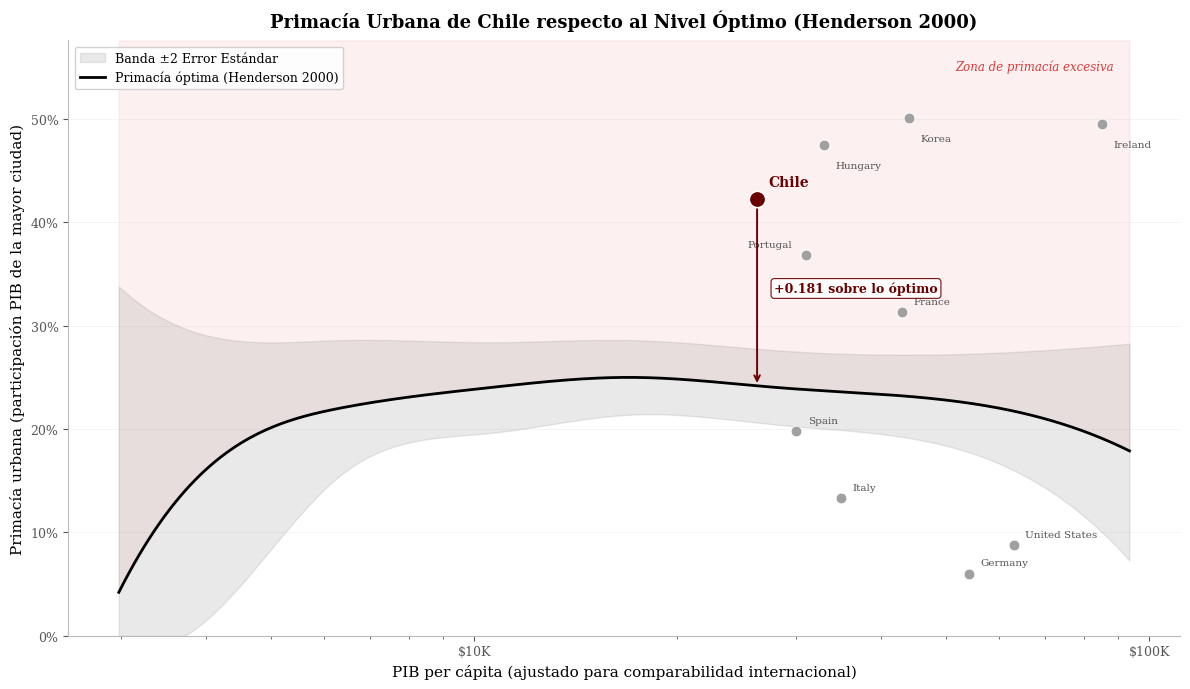

Figura 1 completa.


In [15]:
# ── Figura 1: Chile en la Curva de Primacía Óptima de Henderson ──
print('Figura 1: curva óptima de Henderson...')

# Smooth spline over Henderson data (log income space)
x_h  = df_hend['income_curr'].values.astype(float)
y_h  = df_hend['best_primacy'].values.astype(float)
lo_h = df_hend['lo'].values.astype(float)
hi_h = df_hend['hi'].values.astype(float)

log_x   = np.log(x_h)
# Extender x_fine hasta cubrir todos los países incluido Ireland
x_all_max = max(max(v['gdppc'] for v in COUNTRIES.values()), CHILE_GDPPC) * 1.10
log_xfine = np.linspace(log_x.min(), np.log(x_all_max), 400)
x_fine  = np.exp(log_xfine)

spl_y  = make_interp_spline(log_x, y_h,  k=3)(log_xfine)
spl_lo = make_interp_spline(log_x, lo_h, k=3)(log_xfine).clip(0)
spl_hi = make_interp_spline(log_x, hi_h, k=3)(log_xfine)

# Primacía óptima al nivel de ingreso de Chile (interpolada)
opt_at_chile = float(make_interp_spline(log_x, y_h, k=3)(
    np.log(CHILE_GDPPC)
))
delta = CHILE_PRIMACY - opt_at_chile
print(f'  Primacía óptima al ingreso de Chile (${CHILE_GDPPC:,}): {opt_at_chile:.3f}')
print(f'  Primacía real de Chile:                                  {CHILE_PRIMACY:.3f}')
print(f'  Exceso (delta):                                         +{delta:.3f}')

fig1, ax = plt.subplots(figsize=(12, 7))
fig1.patch.set_facecolor('white')

# Zona de primacía excesiva
# Zona de primacía excesiva — techo dinámico sobre el máximo del gráfico
y_max_plot = max(
    max(v['primacy'] for v in COUNTRIES.values()),
    CHILE_PRIMACY
) * 1.15

ax.fill_between(x_fine, spl_y, y_max_plot,
                alpha=0.06, color='#CC0000', zorder=0)
ax.text(x_fine[-1] * 0.95, y_max_plot * 0.95,
        'Zona de primacía excesiva',
        ha='right', fontsize=8.5, color='#CC0000',
        fontfamily='serif', style='italic', alpha=0.75)

ax.set_ylim(0, y_max_plot)
# Banda de confianza ±2 EE
ax.fill_between(x_fine, spl_lo, spl_hi,
                alpha=0.18, color='#888888', label='Banda ±2 Error Estándar', zorder=1)

# Curva óptima
ax.plot(x_fine, spl_y, color='black', lw=2.0,
        label='Primacía óptima (Henderson 2000)', zorder=3)

# Países OCDE (excluye Chile)
for name, vals in COUNTRIES.items():
    if name == 'Chile':
        continue
    ax.scatter(vals['gdppc'], vals['primacy'],
               s=60, color='#A0A0A0', zorder=4,
               edgecolors='white', lw=0.6)
    dx = vals['gdppc'] * 0.04
    dy = 0.008
    if name in ('Hungary', 'Korea', 'Ireland'):
        dy = -0.022
    if name == 'Portugal':
        dx = -vals['gdppc'] * 0.18
    ax.text(vals['gdppc'] + dx, vals['primacy'] + dy,
            name, fontsize=7.5, color='#555555',
            fontfamily='serif', zorder=5)

# Punto Chile
ax.scatter([CHILE_GDPPC], [CHILE_PRIMACY],
           s=140, color=C_RM, zorder=7,
           edgecolors='white', lw=1.2)
ax.text(CHILE_GDPPC * 1.04, CHILE_PRIMACY + 0.012,
        'Chile', fontsize=10, color=C_RM,
        fontfamily='serif', fontweight='bold', zorder=8)

# Línea de brecha: Chile → curva
ax.annotate(
    '', xy=(CHILE_GDPPC, opt_at_chile),
    xytext=(CHILE_GDPPC, CHILE_PRIMACY),
    arrowprops=dict(arrowstyle='->', color=C_RM, lw=1.4,
                    connectionstyle='arc3,rad=0'),
    zorder=6,
)
ax.text(CHILE_GDPPC * 1.06,
        (CHILE_PRIMACY + opt_at_chile) / 2,
        f'+{delta:.3f} sobre lo óptimo',
        fontsize=9, color=C_RM, fontfamily='serif',
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.25', fc='white',
                  ec=C_RM, lw=0.8, alpha=0.95),
        zorder=9)

_hgrid(ax)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel('PIB per cápita (ajustado para comparabilidad internacional)', fontsize=11)
ax.set_ylabel('Primacía urbana (participación PIB de la mayor ciudad)', fontsize=11)
ax.set_title(
    'Primacía Urbana de Chile respecto al Nivel Óptimo (Henderson 2000)',
    fontsize=13, fontweight='bold', pad=10)
ax.legend(fontsize=9, framealpha=0.9, edgecolor='#CCCCCC',
          loc='upper left')
ax.tick_params(labelsize=9)

 
plt.tight_layout()
save_fig(fig1, 'fig1_henderson_curve')
display(fig1); plt.close()
print('Figura 1 completa.')

Figura 2: participación en PIB regional...
  Saved: figures/fig2_regional_shares.png


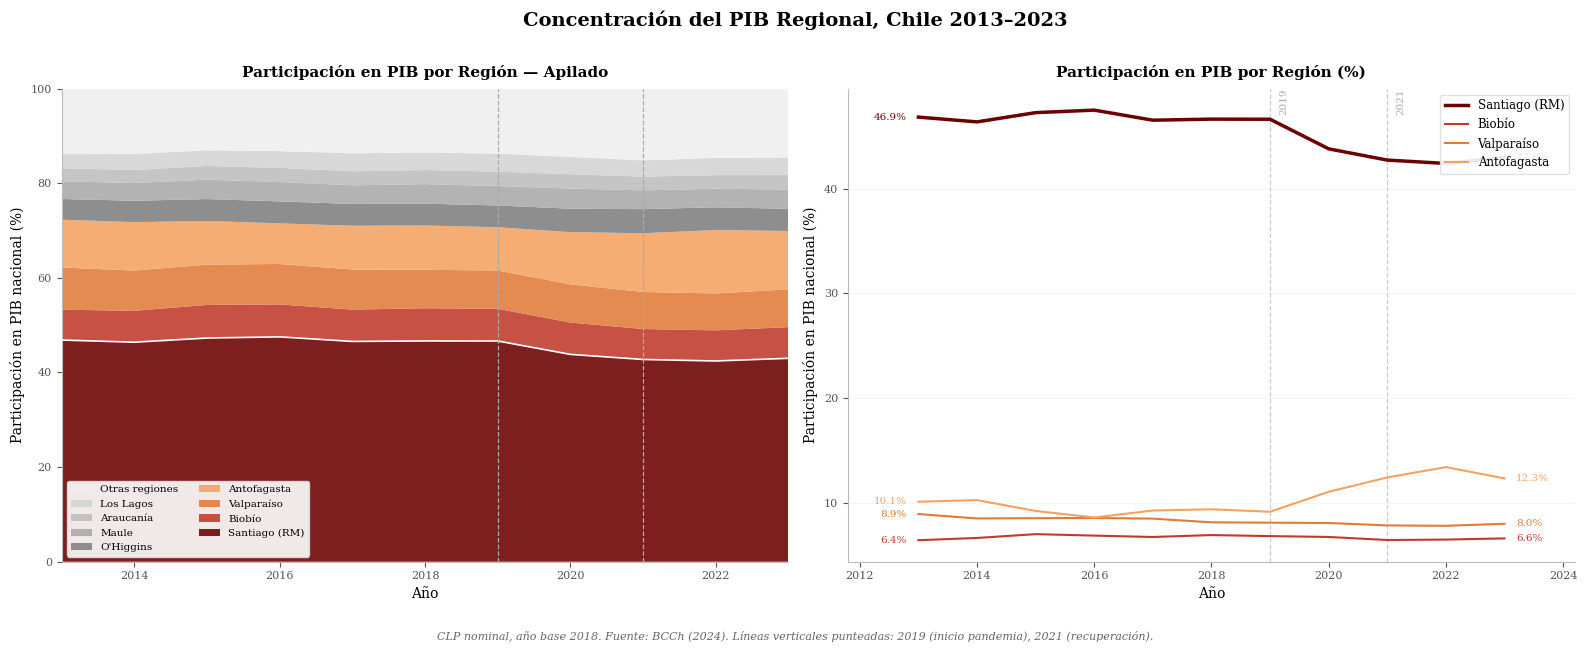

Figura 2 completa.


In [11]:
# ── Figura 2: Concentración del PIB Regional 2013–2023 ────────
print('Figura 2: participación en PIB regional...')

years_arr = np.array(YEARS_PIBR)

# Pivot: filas=año, columnas=región
pivot = (df.pivot_table(index='year', columns='region', values='share_pct')
         .reindex(YEARS_PIBR))

# Orden y colores de graficación
plot_order  = TIER1 + TIER2 + TIER3
plot_colors = [C_RM] + C_T2 + C_T3

other_regions = [c for c in pivot.columns if c not in plot_order]
other_share   = pivot[other_regions].sum(axis=1)

# Datos apilados: orden por tier + otras al tope
stack_data   = [pivot[r].fillna(0).values for r in plot_order]
stack_data.append(other_share.fillna(0).values)
stack_colors = plot_colors + [C_OTHER]
stack_labels = [SHORT.get(r, r) for r in plot_order] + ['Otras regiones']

fig2, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 6))
fig2.patch.set_facecolor('white')

# ── Izquierda: área apilada ───────────────────────────────────
ax_l.stackplot(years_arr, stack_data,
               colors=stack_colors, labels=stack_labels,
               alpha=0.88)

# Línea de participación RM encima para claridad
rm_share = pivot['Región Metropolitana De Santiago'].values
ax_l.plot(years_arr, rm_share, color='white', lw=1.2, zorder=5)

for vyr in VLINES:
    ax_l.axvline(vyr, color='#AAAAAA', lw=0.9, ls='--', zorder=6)

ax_l.set_xlim(YEARS_PIBR[0], YEARS_PIBR[-1])
ax_l.set_ylim(0, 100)
ax_l.set_xlabel('Año', fontsize=10)
ax_l.set_ylabel('Participación en PIB nacional (%)', fontsize=10)
ax_l.set_title('Participación en PIB por Región — Apilado', fontsize=11,
               fontweight='bold', pad=8)
ax_l.tick_params(labelsize=8)
_handles, _labels = ax_l.get_legend_handles_labels()
ax_l.legend(_handles[::-1], _labels[::-1],
            fontsize=7.5, framealpha=0.9, edgecolor='#DDDDDD',
            loc='lower left', ncol=2)
_hgrid(ax_l)

# ── Derecha: líneas individuales (RM + tier 2) ────────────────
line_regions = TIER1 + TIER2
line_colors  = [C_RM] + C_T2
line_widths  = [2.5, 1.5, 1.5, 1.5]

for region, col, lw in zip(line_regions, line_colors, line_widths):
    vals = pivot[region].values
    lbl  = SHORT.get(region, region)
    ax_r.plot(years_arr, vals, color=col, lw=lw, label=lbl, zorder=3)

    ax_r.text(YEARS_PIBR[0] - 0.2, vals[0],
              f'{vals[0]:.1f}%', ha='right', va='center',
              fontsize=7.5, color=col, fontfamily='serif')
    ax_r.text(YEARS_PIBR[-1] + 0.2, vals[-1],
              f'{vals[-1]:.1f}%', ha='left', va='center',
              fontsize=7.5, color=col, fontfamily='serif')

for vyr in VLINES:
    ax_r.axvline(vyr, color='#CCCCCC', lw=0.9, ls='--', zorder=2)
    ax_r.text(vyr + 0.15, ax_r.get_ylim()[1] if ax_r.get_ylim()[1] > 0 else 50,
              str(vyr), fontsize=7.5, color='#AAAAAA',
              fontfamily='serif', rotation=90, va='top')

ax_r.set_xlim(YEARS_PIBR[0] - 1.2, YEARS_PIBR[-1] + 1.2)
ax_r.set_xlabel('Año', fontsize=10)
ax_r.set_ylabel('Participación en PIB nacional (%)', fontsize=10)
ax_r.set_title('Participación en PIB por Región (%)', fontsize=11,
               fontweight='bold', pad=8)
ax_r.tick_params(labelsize=8)
ax_r.legend(fontsize=8.5, framealpha=0.9, edgecolor='#DDDDDD',
            loc='upper right')
_hgrid(ax_r)

fig2.suptitle('Concentración del PIB Regional, Chile 2013–2023',
              fontsize=14, fontweight='bold', y=1.01)
fig2.text(
    0.5, -0.04,
    'CLP nominal, año base 2018. Fuente: BCCh (2024). '
    'Líneas verticales punteadas: 2019 (inicio pandemia), 2021 (recuperación).',
    ha='center', fontsize=8, color='#666666', style='italic')

plt.tight_layout()
save_fig(fig2, 'fig2_regional_shares')
display(fig2); plt.close()
print('Figura 2 completa.')

Figura 3: sigma-convergencia...
  Pendiente OLS: 0.0090/año  R²=0.185  p=0.1872  → Divergencia ↑
  Saved: figures/fig3_sigma_convergence.png


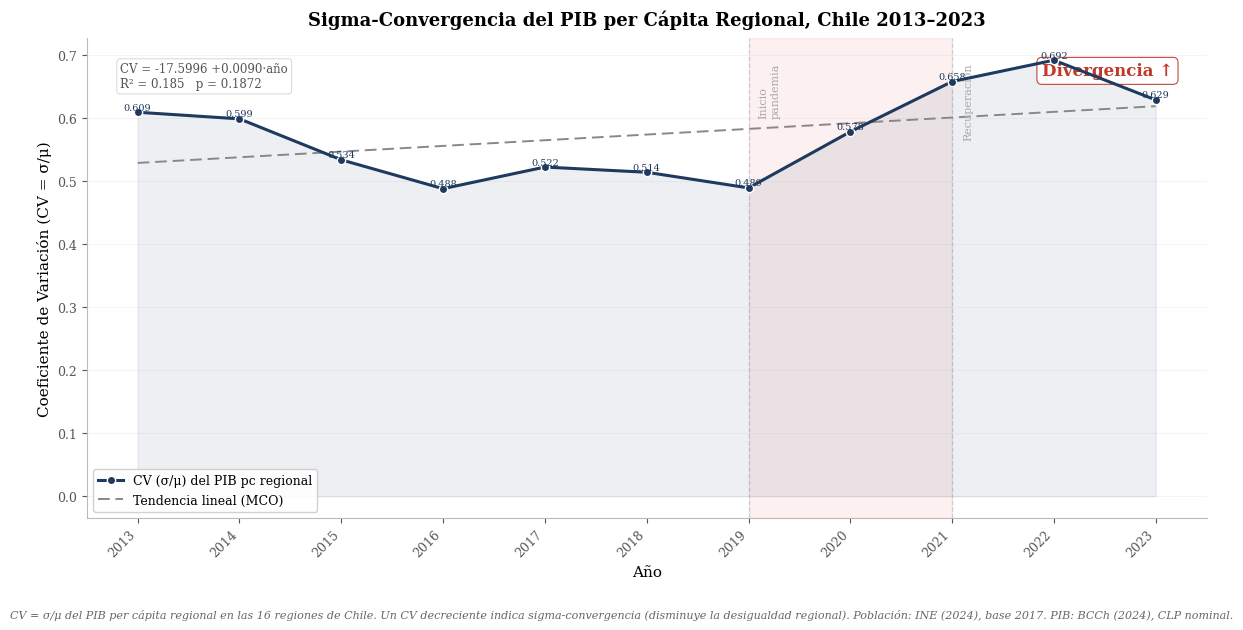

Figura 3 completa.

=== Todo listo ===
Figuras: figures/fig1_henderson_curve.png
         figures/fig2_regional_shares.png
         figures/fig3_sigma_convergence.png
Datos:   data/chile_primacy_summary.csv


In [12]:
# ── Figura 3: Sigma-Convergencia (CV del PIB pc regional) ─────
print('Figura 3: sigma-convergencia...')

cv_series = df_summary[['year', 'cv_regional']].dropna().sort_values('year')
x_cv = cv_series['year'].values.astype(float)
y_cv = cv_series['cv_regional'].values

# Tendencia OLS
slope, intercept, r_value, p_value, se_slope = linregress(x_cv, y_cv)
trend_line = slope * x_cv + intercept
r2 = r_value ** 2
direction  = 'Convergencia ↓' if slope < 0 else 'Divergencia ↑'
dir_color  = '#1A6B1A' if slope < 0 else '#C0392B'
print(f'  Pendiente OLS: {slope:.4f}/año  R²={r2:.3f}  p={p_value:.4f}  → {direction}')

fig3, ax3 = plt.subplots(figsize=(12, 6))
fig3.patch.set_facecolor('white')

# Sombreado pandemia
ax3.axvspan(2019, 2021, alpha=0.06, color='#CC0000', zorder=0)

for vyr in VLINES:
    ax3.axvline(vyr, color='#CCCCCC', lw=0.9, ls='--', zorder=1)

# Línea CV + marcadores
ax3.plot(x_cv, y_cv, color='#1F3A5F', lw=2.2,
         marker='o', ms=6, markerfacecolor='#1F3A5F',
         markeredgecolor='white', markeredgewidth=1.0,
         label='CV (σ/μ) del PIB pc regional', zorder=4)

# Relleno bajo la curva CV
ax3.fill_between(x_cv, y_cv, alpha=0.08, color='#1F3A5F', zorder=2)

# Tendencia OLS
ax3.plot(x_cv, trend_line, color='#888888', lw=1.4,
         ls=(0, (6, 3)), label='Tendencia lineal (MCO)', zorder=3)

# Ecuación + R²
sign_str = '+' if slope >= 0 else ''
eq_str   = (f'CV = {intercept:.4f} {sign_str}{slope:.4f}·año\n'
            f'R² = {r2:.3f}   p = {p_value:.4f}')
ax3.text(0.03, 0.95, eq_str,
         transform=ax3.transAxes, ha='left', va='top',
         fontsize=8.5, color='#555555', fontfamily='serif',
         bbox=dict(boxstyle='round,pad=0.3', fc='white',
                   ec='#CCCCCC', lw=0.6, alpha=0.92))

# Etiqueta dirección de convergencia
ax3.text(0.97, 0.95, direction,
         transform=ax3.transAxes, ha='right', va='top',
         fontsize=12, color=dir_color, fontfamily='serif',
         fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', fc='white',
                   ec=dir_color, lw=0.8, alpha=0.93))

# Anotar cada punto
for xi, yi in zip(x_cv, y_cv):
    ax3.text(xi, yi + 0.004, f'{yi:.3f}',
             ha='center', fontsize=7, color='#1F3A5F',
             fontfamily='serif', zorder=6)

# Etiquetas de líneas verticales
y_lo3, y_hi3 = ax3.get_ylim()
for vyr, lbl in {2019: 'Inicio\npandemia', 2021: 'Recuperación'}.items():
    ax3.text(vyr + 0.1, y_hi3 - (y_hi3 - y_lo3) * 0.05,
             lbl, fontsize=8, color='#AAAAAA',
             fontfamily='serif', rotation=90, va='top')

ax3.set_xlim(YEARS_PIBR[0] - 0.5, YEARS_PIBR[-1] + 0.5)
ax3.set_xticks(YEARS_PIBR)
ax3.set_xticklabels(YEARS_PIBR, rotation=45, ha='right', fontsize=8)
ax3.set_xlabel('Año', fontsize=11)
ax3.set_ylabel('Coeficiente de Variación (CV = σ/μ)', fontsize=11)
ax3.set_title(
    'Sigma-Convergencia del PIB per Cápita Regional, Chile 2013–2023',
    fontsize=13, fontweight='bold', pad=10)
ax3.legend(fontsize=9, framealpha=0.9, edgecolor='#CCCCCC',
           loc='lower left')
ax3.tick_params(labelsize=9)
_hgrid(ax3)

fig3.text(
    0.5, -0.04,
    'CV = σ/μ del PIB per cápita regional en las 16 regiones de Chile. '
    'Un CV decreciente indica sigma-convergencia (disminuye la desigualdad regional). '
    'Población: INE (2024), base 2017. PIB: BCCh (2024), CLP nominal.',
    ha='center', fontsize=8, color='#666666', style='italic')

plt.tight_layout()
save_fig(fig3, 'fig3_sigma_convergence')
display(fig3); plt.close()
print('Figura 3 completa.')
print()
print('=== Todo listo ===')
print('Figuras: figures/fig1_henderson_curve.png')
print('         figures/fig2_regional_shares.png')
print('         figures/fig3_sigma_convergence.png')
print('Datos:   data/chile_primacy_summary.csv')